In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from collections import Counter
import re

data = pd.read_pickle('../data/processed/data_with_pdf_text.pkl')
print(data.shape)
print(data['User type'].value_counts())

(1216, 74)
User type
Company/Business organisation          150
NGO (Non-governmental organisation)    117
EU Citizen                             115
Academic/Research Institution          112
Business Association                   111
Other                                   62
Public authority                        43
Trade Union                             21
Non-EU Citizen                          17
Consumer Organisation                    7
Environmental Organisation               1
Name: count, dtype: int64


In [2]:
# Identify the main free-text columns from the survey
text_cols = [
    'Are there other actions that should be considered?\n',
    'Do you have any further considerations regarding the question above?',
    'What is the best way to ensure that AI is trustworthy, secure and in respect of European values and rules?',
]

def combine_text(row):
    if pd.notna(row['pdf_text']):
        return row['pdf_text']
    # Fall back to concatenating free text survey answers
    parts = [str(row[c]) for c in text_cols if pd.notna(row[c])]
    return ' '.join(parts) if parts else None

data['full_text'] = data.apply(combine_text, axis=1)
print(f"Rows with usable text: {data['full_text'].notna().sum()}")

Rows with usable text: 1150


In [3]:
# Define keywords to track
keywords = ['innovation', 'fundamental rights', 'liability', 'transparency', 
            'human oversight', 'data', 'risk', 'trust', 'regulation', 'ethics']

def count_keywords(text, keywords):
    if pd.isna(text):
        return {k: 0 for k in keywords}
    text = text.lower()
    return {k: len(re.findall(r'\b' + k + r'\b', text)) for k in keywords}

# Apply to all rows
kw_counts = data['full_text'].apply(lambda t: count_keywords(t, keywords))
kw_df = pd.DataFrame(kw_counts.tolist())
kw_df['User type'] = data['User type'].values

# Average keyword frequency per actor type
result = kw_df.groupby('User type')[keywords].mean()
print(result.round(2))

                                     innovation  fundamental rights  \
User type                                                             
Academic/Research Institution              2.59                1.07   
Business Association                       2.70                0.53   
Company/Business organisation              2.54                0.61   
Consumer Organisation                      0.14                0.00   
EU Citizen                                 0.39                0.21   
Environmental Organisation                 1.00                0.00   
NGO (Non-governmental organisation)        2.50                2.93   
Non-EU Citizen                             0.47                0.35   
Other                                      2.63                1.08   
Public authority                           0.74                0.30   
Trade Union                                0.38                0.14   

                                     liability  transparency  human oversigh

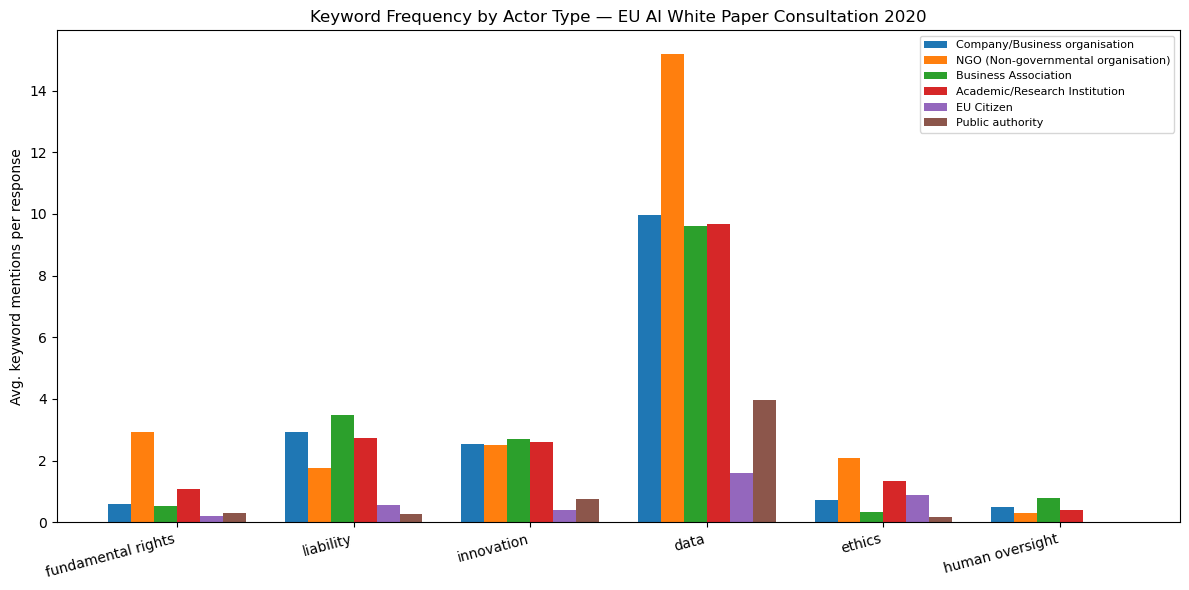

In [4]:
import numpy as np

plot_keywords = ['fundamental rights', 'liability', 'innovation', 'data', 'ethics', 'human oversight']

main_actors = ['Company/Business organisation', 'NGO (Non-governmental organisation)', 
               'Business Association', 'Academic/Research Institution', 'EU Citizen', 'Public authority']

plot_data = result.loc[main_actors, plot_keywords]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(plot_keywords))
width = 0.13

for i, actor in enumerate(main_actors):
    ax.bar(x + i*width, plot_data.loc[actor], width, label=actor)

ax.set_xticks(x + width*2.5)
ax.set_xticklabels(plot_keywords, rotation=15, ha='right')
ax.set_ylabel('Avg. keyword mentions per response')
ax.set_title('Keyword Frequency by Actor Type — EU AI White Paper Consultation 2020')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../data/processed/keyword_by_actor.png', dpi=150)
plt.show()

In [7]:
import subprocess
subprocess.run(['conda', 'install', '-c', 'conda-forge', 'gensim', 'pyldavis', 'textblob', '-y'])

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
done
done




==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c defaults conda





## Package Plan ##

  environment location: /opt/anaconda3

  added / updated specs:
    - gensim
    - pyldavis
    - textblob


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.2.25  |       hbd8a1cb_0         144 KB  conda-forge
    certifi-2026.2.25          |     pyhd8ed1ab_0         148 KB  conda-forge
    conda-25.7.0               |  py313h8f79df9_0         1.2 MB  conda-forge
    fst-pso-1.8.1              |     pyhd8ed1ab_0          26 KB  conda-forge
    funcy-2.0                  |     pyhd8ed1ab_1          30 KB  conda-forge
    future-1.0.0               |     pyhd8ed1ab_2         356 KB  conda-forge
    fuzzytm-2.0.5              |     pyhd8ed1ab_0          24 KB  conda-forge
    gensim-4.4.0               |  py313h50f4ffc_0        40.9 MB
    libcxx-22.1.0              |       h55c6f16_1         556 KB  conda-forge
    miniful-0.0.6              |    

CompletedProcess(args=['conda', 'install', '-c', 'conda-forge', 'gensim', 'pyldavis', 'textblob', '-y'], returncode=0)

In [8]:
import gensim
from gensim import corpora
from gensim.models import LdaModel
from gensim.parsing.preprocessing import STOPWORDS
from gensim.utils import simple_preprocess

def preprocess(text):
    if pd.isna(text):
        return []
    tokens = simple_preprocess(str(text), deacc=True)
    return [t for t in tokens if t not in STOPWORDS and len(t) > 3]

# Apply to all rows with text
data['tokens'] = data['full_text'].apply(preprocess)

# Filter out empty
lda_data = data[data['tokens'].map(len) > 0].copy()
print(f"Documents for LDA: {len(lda_data)}")

Documents for LDA: 1150


In [11]:
import subprocess
subprocess.run(['conda', 'install', '-c', 'conda-forge', 'langdetect', '-y'])

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Collectdone
done / 




==> WARNING: A newer version of conda exists. <==
    current version: 25.7.0
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c conda-forge conda





## Package Plan ##

  environment location: /opt/anaconda3

  added / updated specs:
    - langdetect


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    langdetect-1.0.9           |     pyhd8ed1ab_1         857 KB  conda-forge
    ------------------------------------------------------------
                                           Total:         857 KB

The following NEW packages will be INSTALLED:

  langdetect         conda-forge/noarch::langdetect-1.0.9-pyhd8ed1ab_1 



 done                                                                                                                                                                      
Preparing transaction: done
donefying transaction: - 
Executing tdone


CompletedProcess(args=['conda', 'install', '-c', 'conda-forge', 'langdetect', '-y'], returncode=0)

In [12]:
from langdetect import detect

def detect_lang(text):
    try:
        return detect(str(text))
    except:
        return 'unknown'


In [13]:
lda_data['language'] = lda_data['full_text'].apply(detect_lang)
print(lda_data['language'].value_counts())
print(f"\nEnglish docs: {(lda_data['language'] == 'en').sum()}")
print(f"Non-English docs: {(lda_data['language'] != 'en').sum()}")

# Also check if non-English skews toward certain actor types
print(lda_data[lda_data['language'] != 'en']['User type'].value_counts())

language
en    999
de     55
fr     40
es     23
it     13
nl      4
sv      3
da      3
pt      2
fi      2
hu      1
pl      1
sl      1
hr      1
sk      1
ro      1
Name: count, dtype: int64

English docs: 999
Non-English docs: 151
User type
EU Citizen                             18
NGO (Non-governmental organisation)    17
Public authority                       13
Academic/Research Institution          12
Other                                  11
Business Association                   10
Company/Business organisation           7
Trade Union                             6
Consumer Organisation                   2
Environmental Organisation              1
Name: count, dtype: int64


In [20]:
lda_data_en = lda_data[lda_data['language'] == 'en'].copy()
print(f"Documents for LDA: {len(lda_data_en)}")

dictionary = corpora.Dictionary(lda_data_en['tokens'])
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(doc) for doc in lda_data_en['tokens']]

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=9,
    random_state=42,
    passes=10,
    alpha='auto'
)

for idx, topic in lda_model.print_topics(num_words=8):
    print(f"Topic {idx}: {topic}\n")

Documents for LDA: 999
Topic 0: 0.016*"data" + 0.015*"risk" + 0.010*"rights" + 0.008*"applications" + 0.008*"paper" + 0.007*"high" + 0.007*"european" + 0.007*"human"

Topic 1: 0.022*"discrimination" + 0.014*"data" + 0.012*"note" + 0.011*"supra" + 0.010*"case" + 0.007*"automated" + 0.007*"https" + 0.007*"fairness"

Topic 2: 0.043*"shall" + 0.033*"article" + 0.019*"malta" + 0.018*"person" + 0.017*"office" + 0.016*"constitution" + 0.014*"house" + 0.013*"public"

Topic 3: 0.016*"risk" + 0.013*"systems" + 0.010*"commission" + 0.010*"european" + 0.010*"paper" + 0.010*"applications" + 0.009*"assessment" + 0.009*"white"

Topic 4: 0.024*"data" + 0.013*"liability" + 0.008*"european" + 0.008*"training" + 0.007*"women" + 0.006*"commission" + 0.005*"legal" + 0.005*"risks"

Topic 5: 0.016*"risk" + 0.012*"data" + 0.009*"commission" + 0.009*"high" + 0.008*"systems" + 0.007*"safety" + 0.007*"requirements" + 0.006*"liability"

Topic 6: 0.026*"data" + 0.011*"health" + 0.008*"rights" + 0.007*"european" + 

In [22]:
# Assign dominant topic to each document
def get_dominant_topic(bow):
    topics = lda_model.get_document_topics(bow)
    return max(topics, key=lambda x: x[1])[0]

lda_data_en['dominant_topic'] = [get_dominant_topic(doc) for doc in corpus]

# Label the topics
topic_labels = {
    0: 'Fundamental Rights & High-risk',
    1: 'Discrimination & Fairness',
    2: 'Legal/Constitutional',
    3: 'Risk Assessment',
    4: 'Liability & Training Data',
    5: 'Safety & Compliance',
    6: 'Health Data & Protection',
    7: 'Digital Strategy & Research',
    8: 'General Opinion'
}

lda_data_en['topic_label'] = lda_data_en['dominant_topic'].map(topic_labels)

# Cross-tabulate actor type vs topic
topic_actor = pd.crosstab(
    lda_data_en['User type'], 
    lda_data_en['topic_label'],
    normalize='index'  # percentage of each actor's docs per topic
) * 100

print(topic_actor.round(1))

topic_label                          Digital Strategy & Research  \
User type                                                          
Academic/Research Institution                               37.0   
Business Association                                        22.9   
Company/Business organisation                               35.7   
Consumer Organisation                                        0.0   
EU Citizen                                                  14.0   
NGO (Non-governmental organisation)                         36.0   
Non-EU Citizen                                               5.9   
Other                                                       20.4   
Public authority                                            29.2   
Trade Union                                                 13.3   

topic_label                          Discrimination & Fairness  \
User type                                                        
Academic/Research Institution                      

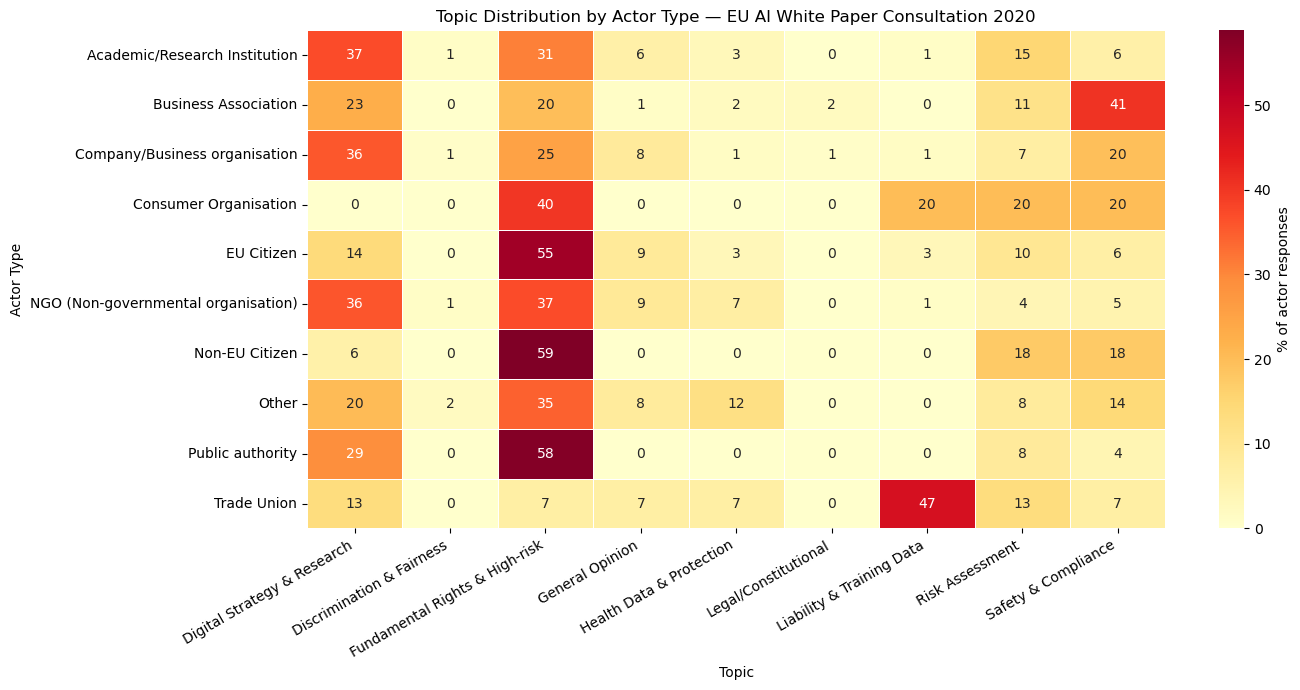

In [21]:
topic_labels = {
    0: 'Fundamental Rights & High-risk',
    1: 'Discrimination & Fairness',
    2: 'Legal/Constitutional',
    3: 'Risk Assessment',
    4: 'Liability & Training Data',
    5: 'Safety & Compliance',
    6: 'Health Data & Protection',
    7: 'Digital Strategy & Research',
    8: 'General Opinion'
}

lda_data_en['dominant_topic'] = [get_dominant_topic(doc) for doc in corpus]
lda_data_en['topic_label'] = lda_data_en['dominant_topic'].map(topic_labels)

topic_actor = pd.crosstab(
    lda_data_en['User type'],
    lda_data_en['topic_label'],
    normalize='index'
) * 100

plt.figure(figsize=(14, 7))
sns.heatmap(
    topic_actor,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': '% of actor responses'}
)
plt.title('Topic Distribution by Actor Type — EU AI White Paper Consultation 2020')
plt.xlabel('Topic')
plt.ylabel('Actor Type')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/topic_heatmap_9.png', dpi=150)
plt.show()

In [27]:
# Map string responses to numeric values
likert_map = {
    '5 - Very important': 5,
    '4 - Important': 4,
    '3 - Neutral': 3,
    '2 - Not important': 2,
    '1 - Not important at all': 1,
    'No opinion': None
}

# Reload raw data and apply mapping
raw = pd.read_csv('../data/contributions-AIConsult2020.csv', encoding='latin-1', sep=';', on_bad_lines='skip')

likert_cols = [c for c in raw.columns if '1-5' in c]

for col in likert_cols:
    raw[col] = raw[col].map(likert_map)

# Short display names
short_names = {c: c.split('?\n: ')[-1].strip() for c in likert_cols}

# Mean score per actor type
likert_means = raw.groupby('User type')[likert_cols].mean().rename(columns=short_names)

print(likert_means.round(2).to_string())

                                     Working with Member states  Focussing the efforts of the research and innovation community  Skills  Focus on SMEs  Partnership with the private sector  Promoting the adoption of AI by the public sector  Strengthen excellence in research  Establish world-reference testing facilities for AI  Promote the uptake of AI by business and the public sector  Increase the financing for start-ups innovating in AI  Develop skills for AI and adapt existing training programmes  Build up the European data space  Support the establishment of a lighthouse research centre that is world class and able to attract the best minds  Network of existing AI research excellence centres  Set up a public-private partnership for industrial research  Help to raise SMEs awareness about potential benefits of AI  Provide access to testing and reference facilities  Promote knowledge transfer and support the development of AI expertise for SMEs  Support partnerships between SMEs, larg

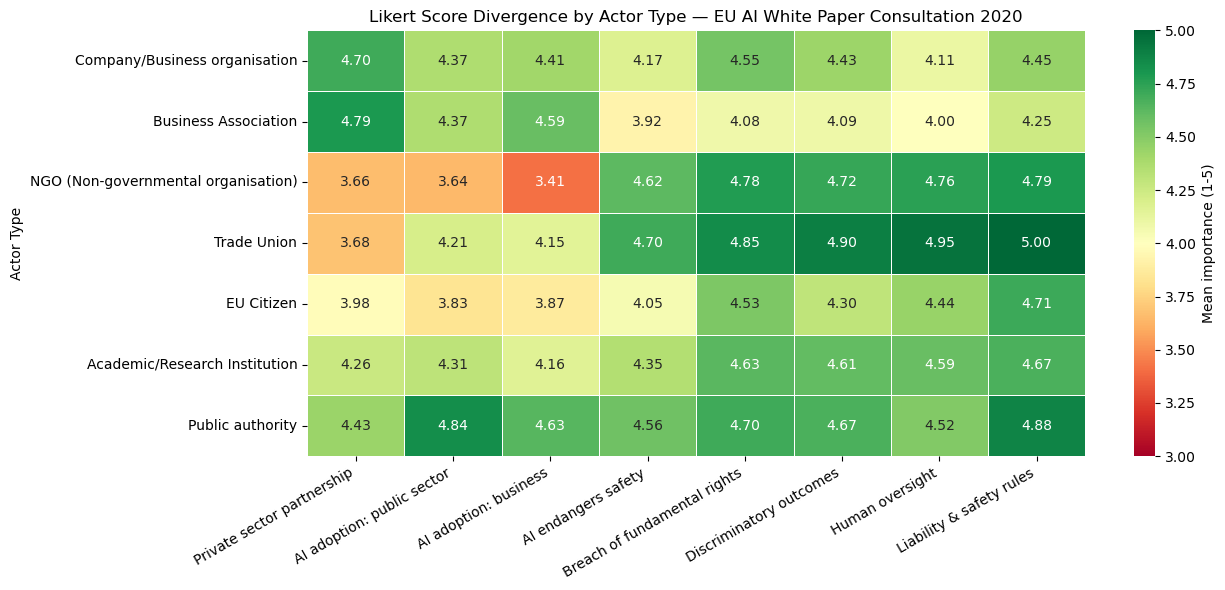

In [30]:
key_questions = [
    'Partnership with the private sector',
    'Promoting the adoption of AI by the public sector',
    'Promote the uptake of AI by business and the public sector',
    'AI may endanger safety',
    "AI may breach fundamental rights (such as human dignity, privacy, data protection, freedom of expression, workers' rights etc.)",
    'The use of AI may lead to discriminatory outcomes',
    'In your opinion, how important are the following mandatory requirements of a possible future regulatory framework for AI (as section 5.D of the White Paper) (1-5: 1 is not important at all, 5 is very important)?: Human oversight',
    'In your opinion, how important are the following mandatory requirements of a possible future regulatory framework for AI (as section 5.D of the White Paper) (1-5: 1 is not important at all, 5 is very important)?: Clear liability and safety rules'
]

main_actors = ['Company/Business organisation', 'Business Association',
               'NGO (Non-governmental organisation)', 'Trade Union',
               'EU Citizen', 'Academic/Research Institution', 'Public authority']

plot_data = likert_means.loc[main_actors, key_questions].copy()

short_labels = [
    'Private sector partnership',
    'AI adoption: public sector',
    'AI adoption: business',
    'AI endangers safety',
    'Breach of fundamental rights',
    'Discriminatory outcomes',
    'Human oversight',
    'Liability & safety rules',
]
plot_data.columns = short_labels

plt.figure(figsize=(13, 6))
sns.heatmap(
    plot_data,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=3.0,
    vmax=5.0,
    linewidths=0.5,
    cbar_kws={'label': 'Mean importance (1-5)'}
)
plt.title('Likert Score Divergence by Actor Type — EU AI White Paper Consultation 2020')
plt.xlabel('')
plt.ylabel('Actor Type')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/likert_heatmap.png', dpi=150)
plt.show()